# Kredi Kartı Temerrüt Tahmini — Sınıflandırma Pipeline'ı

**Araştırma Sorusu:** Demografik özellikler ve ödeme geçmişi, bir müşterinin bir sonraki ay temerrüde düşüp düşmeyeceğini tahmin edebilir mi? Farklı sınıflandırıcılar ve sınıf dengesizliği stratejileri bu problemde nasıl karşılaştırılır?

**Dataset:** UCI Default of Credit Card Clients  
- 30.000 kayıt, 23 özellik, 1 hedef değişken  
- Hedef: 0 = ödeme yapacak, 1 = temerrüde düşecek (~22% pozitif → sınıf dengesizliği)

**Pipeline yapısı:**
1. **EDA** — Veriyi tanı
2. **Preprocessing** — Geçersiz değer düzeltme + StandardScaler *(sabit)*
3. **Ana Deney** — 4 model × 3 sınıf dengesizliği stratejisi, 5-fold Stratified CV
4. **Görselleştirme** — ROC eğrisi, Confusion Matrix, Feature Importance

**Karşılaştırma eksenleri:**
| Karar noktası | Yaklaşım |
|---|---|
| Geçersiz kategorik değerler | Sabit: "Diğer" kategorisine birleştir |
| Ölçekleme | Sabit: StandardScaler |
| Sınıf dengesizliği | ⭐ Karşılaştır: None vs class_weight vs SMOTE |
| Modeller | ⭐ Karşılaştır: DT, NB, KNN, RF |
| Doğrulama yöntemi | Sabit: 5-fold Stratified CV |

## Adım 1 — EDA (Veriyi Tanıma)

Veriyi ilk kez görüyoruz: boyutu, ilk satırlar, temel istatistikler, eksik değer kontrolü, hedef dağılımı.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data_loader import load_dataset

X, y, _variables = load_dataset()

print(_variables)

# Veriyi düzleştir: tek bir DataFrame yap
df = X.copy()
df['default'] = y.values  # hedef sütunu ekle

# --- Temel bilgiler ---
print("=== Boyut ===")
print(f"Satır: {df.shape[0]:,}  |  Sütun: {df.shape[1]}")

print("\n=== İlk 5 satır ===")
display(df.head())

print("\n=== Temel istatistikler ===")
display(df.describe().round(2))

print("\n=== Eksik değer sayısı ===")
print(df.isnull().sum().sum(), "eksik değer bulundu.")

print("\n=== Hedef değişken dağılımı ===")
counts = df['default'].value_counts()
pct = df['default'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Adet': counts, 'Yüzde (%)': pct.round(1)}))

   X : 30,000 satır × 23 sütun | dtype: int64
   y : 30,000 satır × 1 sütun | sütun: 'default'
   name     role     type      demographic                 description  units  \
0    ID       ID  Integer              NaN                         NaN    NaN   
1    X1  Feature  Integer              NaN                   LIMIT_BAL    NaN   
2    X2  Feature  Integer              Sex                         SEX    NaN   
3    X3  Feature  Integer  Education Level                   EDUCATION    NaN   
4    X4  Feature  Integer   Marital Status                    MARRIAGE    NaN   
5    X5  Feature  Integer              Age                         AGE    NaN   
6    X6  Feature  Integer              NaN                       PAY_0    NaN   
7    X7  Feature  Integer              NaN                       PAY_2    NaN   
8    X8  Feature  Integer              NaN                       PAY_3    NaN   
9    X9  Feature  Integer              NaN                       PAY_4    NaN   
10  X10  Featu

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0



=== Temel istatistikler ===


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,default
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,...,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,167484.32,1.60,1.85,1.55,35.49,-0.02,-0.13,-0.17,-0.22,-0.27,...,43262.95,40311.40,38871.76,5663.58,5921.16,5225.68,4826.08,4799.39,5215.50,0.22
std,129747.66,0.49,0.79,0.52,9.22,1.12,1.20,1.20,1.17,1.13,...,64332.86,60797.16,59554.11,16563.28,23040.87,17606.96,15666.16,15278.31,17777.47,0.42
min,10000.00,1.00,0.00,0.00,21.00,-2.00,-2.00,-2.00,-2.00,-2.00,...,-170000.00,-81334.00,-339603.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,50000.00,1.00,1.00,1.00,28.00,-1.00,-1.00,-1.00,-1.00,-1.00,...,2326.75,1763.00,1256.00,1000.00,833.00,390.00,296.00,252.50,117.75,0.00
50%,140000.00,2.00,2.00,2.00,34.00,0.00,0.00,0.00,0.00,0.00,...,19052.00,18104.50,17071.00,2100.00,2009.00,1800.00,1500.00,1500.00,1500.00,0.00
75%,240000.00,2.00,2.00,2.00,41.00,0.00,0.00,0.00,0.00,0.00,...,54506.00,50190.50,49198.25,5006.00,5000.00,4505.00,4013.25,4031.50,4000.00,0.00
max,1000000.00,2.00,6.00,3.00,79.00,8.00,8.00,8.00,8.00,8.00,...,891586.00,927171.00,961664.00,873552.00,1684259.00,896040.00,621000.00,426529.00,528666.00,1.00



=== Eksik değer sayısı ===
0 eksik değer bulundu.

=== Hedef değişken dağılımı ===
          Adet  Yüzde (%)
default                  
0        23364       77.9
1         6636       22.1


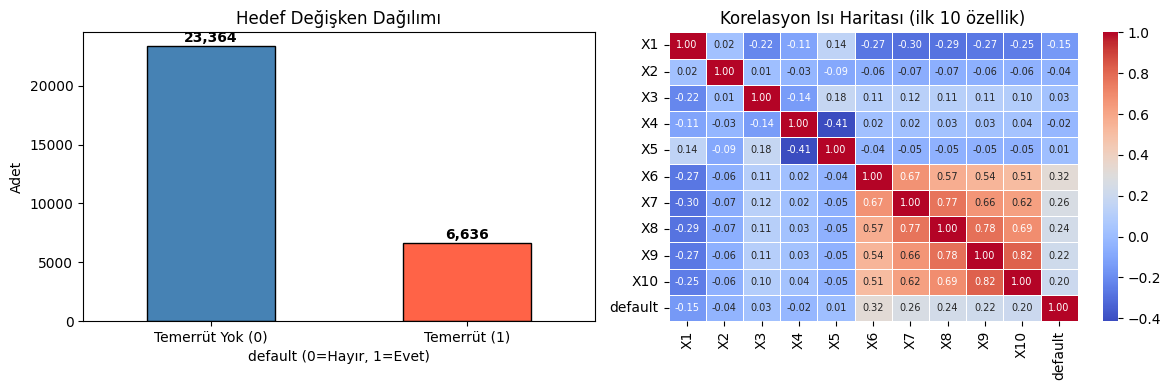

Not: ~78% negatif, ~22% pozitif → class imbalance var.


In [2]:
# --- Görsel 1: Hedef dağılımı (class imbalance) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Hedef Değişken Dağılımı')
axes[0].set_xlabel('default (0=Hayır, 1=Evet)')
axes[0].set_ylabel('Adet')
axes[0].set_xticklabels(['Temerrüt Yok (0)', 'Temerrüt (1)'], rotation=0)
for bar, count in zip(axes[0].patches, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold')

# Korelasyon ısı haritası (ilk 10 özellik, okunabilirlik için)
top_cols = list(X.columns[:10]) + ['default']
corr = df[top_cols].corr()
sns.heatmap(corr, ax=axes[1], annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7})
axes[1].set_title('Korelasyon Isı Haritası (ilk 10 özellik)')

plt.tight_layout()
plt.show()
print("Not: ~78% negatif, ~22% pozitif → class imbalance var.")


## Adım 2 — Preprocessing *(sabit kararlar)*

Bu adımdaki kararlar tüm deneyler boyunca aynı kalır — karşılaştırma ekseni değildir.

- **Geçersiz kategorik değerler:** EDUCATION ve MARRIAGE'daki belgelenmemiş değerler → "Diğer" kategorisine birleştirilir
- **Ölçekleme:** StandardScaler — pipeline içinde uygulanır (her CV fold'unda sadece eğitim verisine fit edilir → data leakage önlenir)
- Sınıf dengesizliği bu adımda ele alınmaz → Ana deneyde karşılaştırmalı olarak işlenecek

In [3]:
from sklearn.preprocessing import StandardScaler

# --- Kopyayı al (orijinal X'i bozmamak için) ---
X_clean = X.copy()

# =====================================================================
# ÖNCE: Ham verideki gerçek değerleri say —
# hangi değerler var, kaç kez geçiyor?
# Dokümantasyon ne diyorsa desin, veriyi biz kontrol ediyoruz.
# =====================================================================
print("=== X3 (EDUCATION) — ham değer dağılımı ===")
print(X_clean['X3'].value_counts().sort_index())
print("\nDokümantasyona göre geçerli değerler: 1=Yüksek Lisans, 2=Üniversite, 3=Lise, 4=Diğer")
print("Yukarıda bunların dışında değer görünüyorsa → belgelenmemiş → 'Diğer' (4) yapacağız\n")

print("=== X4 (MARRIAGE) — ham değer dağılımı ===")
print(X_clean['X4'].value_counts().sort_index())
print("\nDokümantasyona göre geçerli değerler: 1=Evli, 2=Bekar, 3=Diğer")
print("0 görünüyorsa → belgelenmemiş → 'Diğer' (3) yapacağız\n")

# =====================================================================
# SONRA: Gördüklerimize göre düzeltelim
# =====================================================================
gecerli_X3 = {1, 2, 3, 4}
gecerli_X4 = {1, 2, 3}

gecersiz_X3 = set(X_clean['X3'].unique()) - gecerli_X3
gecersiz_X4 = set(X_clean['X4'].unique()) - gecerli_X4
print(f"X3'te geçersiz değerler (düzeltilecek): {sorted(gecersiz_X3)}")
print(f"X4'te geçersiz değerler (düzeltilecek): {sorted(gecersiz_X4)}")

X_clean['X3'] = X_clean['X3'].replace({v: 4 for v in gecersiz_X3})
X_clean['X4'] = X_clean['X4'].replace({v: 3 for v in gecersiz_X4})

print("\n--- Düzeltme sonrası ---")
print("X3 unique:", sorted(X_clean['X3'].unique()), "  ← sadece 1,2,3,4 kalmalı")
print("X4 unique:", sorted(X_clean['X4'].unique()), "  ← sadece 1,2,3 kalmalı")

# --- Hedef değişkeni düzleştir (1D array yap) ---
y_arr = y.values.ravel()  # shape (30000,)

# --- StandardScaler burada YAPILMIYOR ---
# Neden? Tüm veriye fit etmek data leakage yaratır.
# Scaler, pipeline içine taşındı → her CV fold'unda sadece eğitim
# verisine fit edilip test verisine transform uygulanır.
X_processed = X_clean.values  # numpy array'e çevir (pipeline için)

print(f"\nX_processed shape: {X_processed.shape}")
print(f"y_arr shape: {y_arr.shape}")
print("StandardScaler pipeline içinde uygulanacak (data leakage önlenir).")


=== X3 (EDUCATION) — ham değer dağılımı ===
X3
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

Dokümantasyona göre geçerli değerler: 1=Yüksek Lisans, 2=Üniversite, 3=Lise, 4=Diğer
Yukarıda bunların dışında değer görünüyorsa → belgelenmemiş → 'Diğer' (4) yapacağız

=== X4 (MARRIAGE) — ham değer dağılımı ===
X4
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

Dokümantasyona göre geçerli değerler: 1=Evli, 2=Bekar, 3=Diğer
0 görünüyorsa → belgelenmemiş → 'Diğer' (3) yapacağız

X3'te geçersiz değerler (düzeltilecek): [np.int64(0), np.int64(5), np.int64(6)]
X4'te geçersiz değerler (düzeltilecek): [np.int64(0)]

--- Düzeltme sonrası ---
X3 unique: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]   ← sadece 1,2,3,4 kalmalı
X4 unique: [np.int64(1), np.int64(2), np.int64(3)]   ← sadece 1,2,3 kalmalı

X_processed shape: (30000, 23)
y_arr shape: (30000,)
StandardScaler pipeline içinde uygulanacak (data leakage önleni

## Adım 3 — Ana Deney: 4 Model × 3 Sınıf Dengesizliği Stratejisi

**Doğrulama:** 5-fold Stratified Cross-Validation  
→ Veri 5 parçaya bölünür; her seferinde 4 parça eğitim, 1 parça test olur. 5 sonucun ortalaması alınır.  
→ Tek bir train/test split'e bağımlı olmamız engellenir.

**Sınıf dengesizliği stratejileri:**

| Strateji | Açıklama |
|---|---|
| **None (baseline)** | Hiçbir düzeltme yapılmaz |
| **class_weight='balanced'** | Model, azınlık sınıfa daha fazla ağırlık verir |
| **SMOTE** | Eğitim setinde sentetik azınlık örnekleri üretilir |

**Modeller:** Decision Tree, Naïve Bayes, k-NN (k=5), Random Forest

Not: SMOTE sadece eğitim fold'larına uygulanır (test fold'una dokunulmaz) → `imblearn.pipeline.Pipeline` bunu garanti eder.

In [4]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# --- CV ayarı ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Model tanımları (varsayılan parametreler) ---
base_models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Naïve Bayes':   GaussianNB(),
    'k-NN (k=5)':    KNeighborsClassifier(n_neighbors=5),
    'Random Forest':  RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
}

# --- Sınıf dengesizliği stratejileri ---
# StandardScaler artık pipeline'ın ilk adımı — her fold'da sadece
# eğitim verisine fit edilir, test verisine sadece transform uygulanır.

def make_configs(base_models):
    """4 model × 3 strateji = 12 konfigürasyon üretir."""
    configs = []
    for model_name, model in base_models.items():
        # --- Strateji 1: None (baseline) ---
        pipe_none = ImbPipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        configs.append((model_name, 'None', pipe_none))

        # --- Strateji 2: class_weight='balanced' ---
        if hasattr(model, 'class_weight'):
            import copy
            model_cw = copy.deepcopy(model)
            model_cw.set_params(class_weight='balanced')
            pipe_cw = ImbPipeline([
                ('scaler', StandardScaler()),
                ('model', model_cw)
            ])
        else:
            # NB ve KNN class_weight desteklemiyor → None ile aynı
            pipe_cw = ImbPipeline([
                ('scaler', StandardScaler()),
                ('model', model)
            ])
        configs.append((model_name, 'class_weight', pipe_cw))

        # --- Strateji 3: SMOTE ---
        pipe_smote = ImbPipeline([
            ('scaler', StandardScaler()),
            ('smote', SMOTE(random_state=42)),
            ('model', model)
        ])
        configs.append((model_name, 'SMOTE', pipe_smote))

    return configs

configs = make_configs(base_models)
print(f"Toplam konfigürasyon: {len(configs)}")
for name, strategy, _ in configs:
    print(f"  {name:20s} | {strategy}")


Toplam konfigürasyon: 12
  Decision Tree        | None
  Decision Tree        | class_weight
  Decision Tree        | SMOTE
  Naïve Bayes          | None
  Naïve Bayes          | class_weight
  Naïve Bayes          | SMOTE
  k-NN (k=5)           | None
  k-NN (k=5)           | class_weight
  k-NN (k=5)           | SMOTE
  Random Forest        | None
  Random Forest        | class_weight
  Random Forest        | SMOTE


In [6]:
# --- Deney Konfigürasyonları Tablosu (Rapor için) ---
config_table = pd.DataFrame({
    'Model': ['Decision Tree', 'Naïve Bayes', 'k-NN (k=5)', 'Random Forest'],
    'None (Baseline)': ['✓', '✓', '✓', '✓'],
    'class_weight': ['✓', '—*', '—*', '✓'],
    'SMOTE': ['✓', '✓', '✓', '✓'],
})

print("=== Configurations ===")
print("(✓ = applied, —* = model does not support, same as baseline)\n")
display(config_table.set_index('Model'))
print(f"\nToplam konfigürasyon: {len(configs)} (4 model × 3 strateji)")
print("Not: NB ve KNN class_weight parametresini desteklemez → bu hücrelerde baseline tekrarlanır.")


=== Configurations ===
(✓ = applied, —* = model does not support, same as baseline)



,None (Baseline),class_weight,SMOTE
Model,,,
Decision Tree,✓,✓,✓
Naïve Bayes,✓,—*,✓
k-NN (k=5),✓,—*,✓
Random Forest,✓,✓,✓



Toplam konfigürasyon: 12 (4 model × 3 strateji)
Not: NB ve KNN class_weight parametresini desteklemez → bu hücrelerde baseline tekrarlanır.


### 3.1 — Cross-Validation Çalıştır

12 konfigürasyonun her biri için 5-fold CV çalıştırılır.  
Her fold'da accuracy, precision, recall, F1 ve ROC-AUC hesaplanır → 5 fold'un ortalaması ve standart sapması raporlanır.

In [7]:
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

results = []

print("Cross-validation çalışıyor (12 konfigürasyon × 5 fold = 60 eğitim)...")
for model_name, strategy, pipeline in configs:
    cv_results = cross_validate(
        pipeline, X_processed, y_arr,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    row = {
        'Model': model_name,
        'Strateji': strategy,
    }
    for metric in scoring:
        key = f'test_{metric}'
        row[f'{metric}_mean'] = cv_results[key].mean()
        row[f'{metric}_std']  = cv_results[key].std()

    results.append(row)
    print(f"  ✓ {model_name:20s} | {strategy:12s} | F1={row['f1_mean']:.4f} ± {row['f1_std']:.4f}")

results_df = pd.DataFrame(results)
print("\nTamamlandı.")


Cross-validation çalışıyor (12 konfigürasyon × 5 fold = 60 eğitim)...
  ✓ Decision Tree        | None         | F1=0.4538 ± 0.0142
  ✓ Decision Tree        | class_weight | F1=0.5008 ± 0.0133
  ✓ Decision Tree        | SMOTE        | F1=0.4909 ± 0.0114
  ✓ Naïve Bayes          | None         | F1=0.4951 ± 0.0208
  ✓ Naïve Bayes          | class_weight | F1=0.4951 ± 0.0208
  ✓ Naïve Bayes          | SMOTE        | F1=0.4013 ± 0.0067
  ✓ k-NN (k=5)           | None         | F1=0.4219 ± 0.0086
  ✓ k-NN (k=5)           | class_weight | F1=0.4219 ± 0.0086
  ✓ k-NN (k=5)           | SMOTE        | F1=0.4410 ± 0.0094
  ✓ Random Forest        | None         | F1=0.4666 ± 0.0068
  ✓ Random Forest        | class_weight | F1=0.5404 ± 0.0093
  ✓ Random Forest        | SMOTE        | F1=0.5356 ± 0.0117

Tamamlandı.


### 3.2 — Sonuç Tablosu

12 konfigürasyonun 5-fold CV ortalamaları. Her metrik için `ortalama ± std` gösterilir.  
- **Accuracy** yanıltıcı olabilir (çoğunluk sınıfını tahmin etmek bile ~78% verir)  
- **Recall** gerçek temerrütlerin ne kadarını yakaladığımızı gösterir — class imbalance'ın etkisi burada görülür  
- **F1** precision-recall dengesini özetler  
- **ROC-AUC** eşikten bağımsız genel performans

In [8]:
# --- Sonuç tablosunu düzenle ---
display_df = results_df[['Model', 'Strateji']].copy()

# Okunabilir format: "0.8123 ± 0.0045"
for metric in scoring:
    display_df[metric] = results_df.apply(
        lambda r: f"{r[f'{metric}_mean']:.4f} ± {r[f'{metric}_std']:.4f}", axis=1
    )

print("=== Ana Deney Sonuçları (5-Fold Stratified CV) ===\n")
display(display_df)

# --- En iyi F1 skoru ---
best_idx = results_df['f1_mean'].idxmax()
best = results_df.loc[best_idx]
print(f"\n★ En iyi F1: {best['Model']} + {best['Strateji']} → F1 = {best['f1_mean']:.4f}")


=== Ana Deney Sonuçları (5-Fold Stratified CV) ===



,Model,Strateji,accuracy,precision,recall,f1,roc_auc
0,Decision Tree,None,0.8070 ± 0.0032,0.6075 ± 0.0178,0.3630 ± 0.0219,0.4538 ± 0.0142,0.7256 ± 0.0048
1,Decision Tree,class_weight,0.7347 ± 0.0116,0.4294 ± 0.0165,0.6013 ± 0.0134,0.5008 ± 0.0133,0.7290 ± 0.0057
2,Decision Tree,SMOTE,0.7502 ± 0.0143,0.4485 ± 0.0225,0.5440 ± 0.0218,0.4909 ± 0.0114,0.7149 ± 0.0128
3,Naïve Bayes,None,0.7024 ± 0.0445,0.4030 ± 0.0429,0.6542 ± 0.0472,0.4951 ± 0.0208,0.7367 ± 0.0054
4,Naïve Bayes,class_weight,0.7024 ± 0.0445,0.4030 ± 0.0429,0.6542 ± 0.0472,0.4951 ± 0.0208,0.7367 ± 0.0054
5,Naïve Bayes,SMOTE,0.4225 ± 0.0305,0.2607 ± 0.0080,0.8740 ± 0.0240,0.4013 ± 0.0067,0.7303 ± 0.0045
6,k-NN (k=5),None,0.7913 ± 0.0035,0.5447 ± 0.0130,0.3443 ± 0.0068,0.4219 ± 0.0086,0.7008 ± 0.0076
7,k-NN (k=5),class_weight,0.7913 ± 0.0035,0.5447 ± 0.0130,0.3443 ± 0.0068,0.4219 ± 0.0086,0.7008 ± 0.0076
8,k-NN (k=5),SMOTE,0.6596 ± 0.0078,0.3464 ± 0.0083,0.6070 ± 0.0128,0.4410 ± 0.0094,0.6843 ± 0.0081
9,Random Forest,None,0.8193 ± 0.0034,0.6729 ± 0.0185,0.3571 ± 0.0042,0.4666 ± 0.0068,0.7805 ± 0.0061



★ En iyi F1: Random Forest + class_weight → F1 = 0.5404


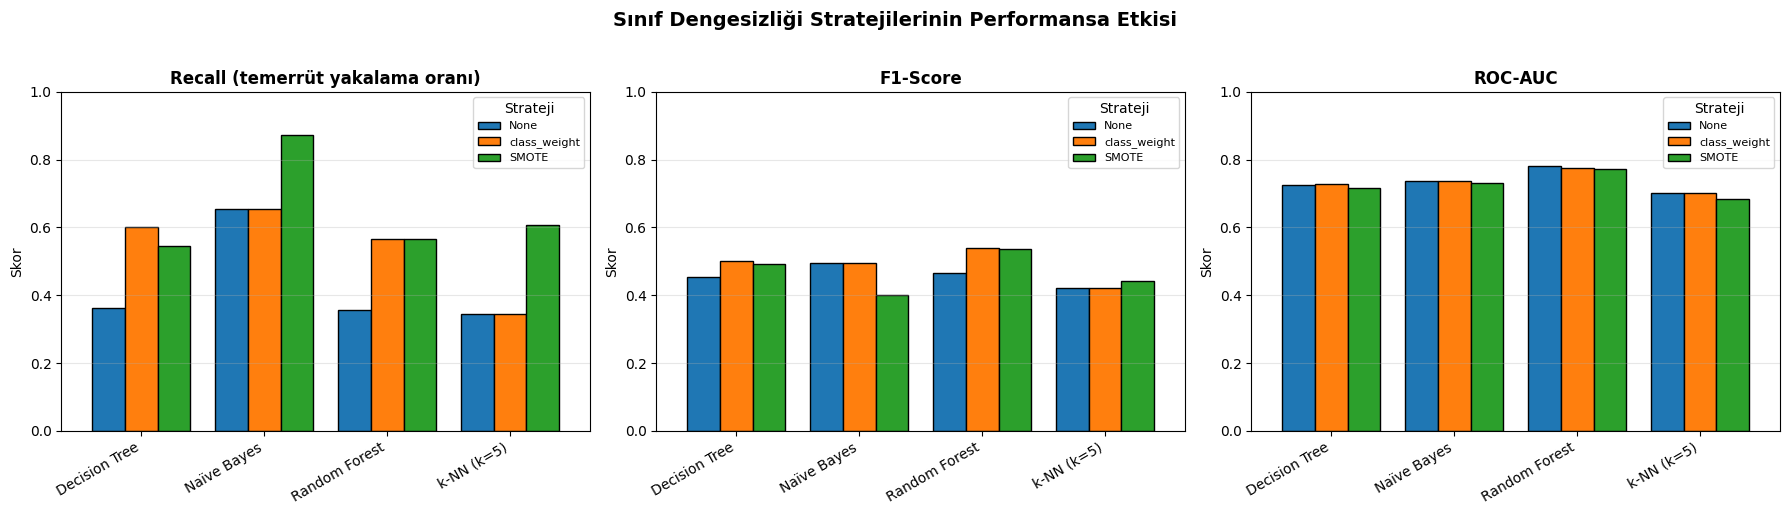

Yorum: None stratejisinde accuracy yüksek ama recall düşük olabilir
→ Model çoğunluk sınıfını tahmin ederek 'kolay' accuracy kazanıyor.
class_weight ve SMOTE recall'u yükseltir ama precision düşebilir.


In [9]:
# --- Görsel: Strateji × Model karşılaştırma grafikleri ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = ['recall_mean', 'f1_mean', 'roc_auc_mean']
titles = ['Recall (temerrüt yakalama oranı)', 'F1-Score', 'ROC-AUC']

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    pivot = results_df.pivot(index='Model', columns='Strateji', values=metric)
    pivot = pivot[['None', 'class_weight', 'SMOTE']]  # sıralama
    pivot.plot(kind='bar', ax=ax, edgecolor='black', width=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Skor')
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.legend(title='Strateji', fontsize=8)
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Sınıf Dengesizliği Stratejilerinin Performansa Etkisi', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Yorum: None stratejisinde accuracy yüksek ama recall düşük olabilir")
print("→ Model çoğunluk sınıfını tahmin ederek 'kolay' accuracy kazanıyor.")
print("class_weight ve SMOTE recall'u yükseltir ama precision düşebilir.")


## Adım 4 — ROC Eğrisi, Confusion Matrix, Feature Importance

ROC eğrisi ve Confusion Matrix için tek bir train/test split kullanıyoruz (CV ortalaması bu grafiklerde gösterilemez).  
Bu split yalnızca görselleştirme amaçlıdır — ana sonuçlar yukarıdaki CV tablosundadır.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
import copy

# --- Ana deneyden en iyi stratejiyi bul ---
best_strategy = results_df.loc[results_df['f1_mean'].idxmax(), 'Strateji']
print(f"En iyi strateji: {best_strategy}\n")

# --- Görselleştirme için tek split (CV sonuçlarını değiştirmez) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_arr, test_size=0.20, random_state=42, stratify=y_arr
)

# Ana deneyden en iyi strateji ile 4 modeli eğit (pipeline scaler içerir)
vis_models = {}
for model_name, model in base_models.items():
    m = copy.deepcopy(model)
    if best_strategy == 'class_weight' and hasattr(m, 'class_weight'):
        m.set_params(class_weight='balanced')
    steps = [('scaler', StandardScaler())]
    if best_strategy == 'SMOTE':
        steps.append(('smote', SMOTE(random_state=42)))
    steps.append(('model', m))
    pipe = ImbPipeline(steps)
    pipe.fit(X_train, y_train)
    vis_models[model_name] = pipe

# === ROC Eğrisi ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['steelblue', 'darkorange', 'green', 'red']
for (name, pipe), color in zip(vis_models.items(), colors):
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Rastgele')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'ROC Eğrisi (strateji: {best_strategy})')
axes[0].legend(loc='lower right', fontsize=8)
axes[0].grid(alpha=0.3)

# === Confusion Matrix (en iyi model) ===
best_model_name = results_df.loc[results_df['f1_mean'].idxmax(), 'Model']
best_pipe = vis_models[best_model_name]
y_pred_best = best_pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Pred: 0', 'Pred: 1'],
            yticklabels=['True: 0', 'True: 1'])
axes[1].set_title(f'Confusion Matrix\n({best_model_name} + {best_strategy})')
axes[1].set_xlabel('Tahmin')
axes[1].set_ylabel('Gerçek')

# === Feature Importance (Random Forest) ===
rf_pipe = vis_models['Random Forest']
rf_model = rf_pipe.named_steps['model']
importances = pd.Series(rf_model.feature_importances_, index=X_clean.columns)
top15 = importances.nlargest(15).sort_values()
top15.plot(kind='barh', ax=axes[2], color='steelblue', edgecolor='black')
axes[2].set_title('Feature Importance (RF, Top 15)')
axes[2].set_xlabel('Önem Skoru')

plt.tight_layout()
plt.show()


## Özet

### Yapılan deneyler:
1. **EDA** — Veri boyutu, dağılım, korelasyon, sınıf dengesizliği tespiti
2. **Preprocessing (sabit)** — Geçersiz kategori düzeltme, StandardScaler
3. **Ana Deney** — 4 model × 3 sınıf dengesizliği stratejisi, 5-fold Stratified CV
4. **Görselleştirme** — ROC eğrisi, Confusion Matrix, Feature Importance

### Rapora taşınacak unsurlar:
- **§IV Methodology:** Preprocessing kararları, CV yöntemi, imbalance stratejileri açıklaması
- **§V Results:** Ana deney tablosu (12 konfigürasyon), görselleştirmeler
- **§VI Discussion:** Class imbalance etkisi yorumu, accuracy'nin yanıltıcılığı, feature importance analizi
- **Figures:** Strateji karşılaştırma bar chart, ROC eğrisi, confusion matrix